# Example usecases of scGPT-annotator

In [1]:
# Evaluate results
import os
from pathlib import Path
import scanpy as sc
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

file_path = r""

In [2]:
adata = sc.read(file_path)

In [3]:
print (adata)

AnnData object with n_obs × n_vars = 140302 × 26232
    obs: 'nCount_RNA', 'nFeature_RNA', 'Size_Factor', 'n.umi', 'scrublet_score', 'scrublet_call', 'sample', 'Ligation_barcode', 'RT_barcode', 'P7_barcode', 'P5_barcode', 'line', 'line_and_time.point', 'time.point', 'perc_mito_umi', 'monocle_cluster', 'sex_ontology_term_id', 'donor_id', 'organism_ontology_term_id', 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_type', 'is_primary_data', 'cluster', 'Xu_S1B_max_cell_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'pred_cell_type', 'pred_cell_type_prob_Schwann cell', 'pred_cell_type_prob_blood cell', 'pred_cell_type_prob_endodermal cell', 'pred_cell_type_prob_endothelial cell', 'pred_cell_type_prob_epidermal cell', 'pred_cell_typ

In [5]:
display(adata.uns['prediction_data'])

,cell_type,pred_cell_type,prediction_confidence,top1_type,top1_prob,top2_type,top2_prob,top3_type,top3_prob,top4_type,top4_prob,top5_type,top5_prob,true_in_top_n
0,endothelial cell,endothelial cell,1.00,endothelial cell,1.00,splanchnic mesodermal cell,0.00,intermediate mesodermal cell,0.00,blood cell,0.00,endodermal cell,0.00,True
1,mesodermal cell,mesodermal cell,0.37,mesodermal cell,0.37,sensory neuron,0.20,primordial germ cell,0.08,epithelial cell,0.07,epidermal cell,0.07,True
2,lateral mesodermal cell,lateral mesodermal cell,0.52,lateral mesodermal cell,0.52,somatic stem cell,0.09,epithelial cell,0.09,intermediate mesodermal cell,0.09,splanchnic mesodermal cell,0.09,True
3,endodermal cell,endodermal cell,0.53,endodermal cell,0.53,epithelial cell,0.34,primordial germ cell,0.04,sensory neuron,0.03,intermediate mesodermal cell,0.02,True
4,paraxial cell,splanchnic mesodermal cell,0.18,splanchnic mesodermal cell,0.18,sensory neuron,0.17,mesodermal cell,0.12,blood cell,0.09,somatic stem cell,0.08,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166080,mesodermal cell,epithelial cell,0.14,epithelial cell,0.14,neural progenitor cell,0.11,paraxial cell,0.09,blood cell,0.08,mesodermal cell,0.08,True
166081,mesodermal cell,epithelial cell,0.13,epithelial cell,0.13,somatic stem cell,0.13,neural progenitor cell,0.12,mesodermal cell,0.10,Schwann cell,0.07,True
166082,mesodermal cell,somatic stem cell,0.21,somatic stem cell,0.21,epithelial cell,0.11,paraxial cell,0.08,blood cell,0.08,neural progenitor cell,0.08,False
166083,neuron,neuron,0.29,neuron,0.29,neural progenitor cell,0.15,primordial germ cell,0.08,mesodermal cell,0.08,endothelial cell,0.07,True


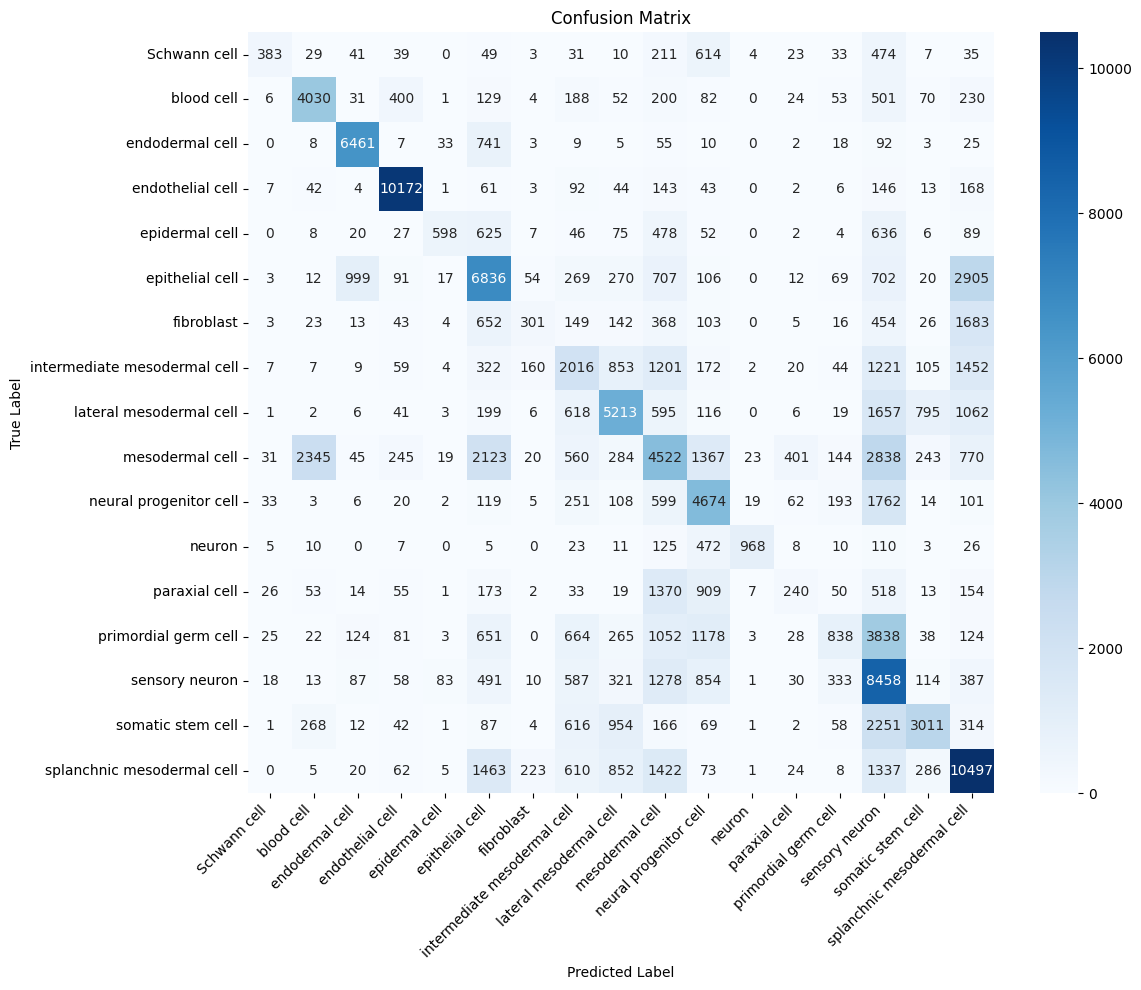

In [7]:
true_labels = adata.obs['cell_type']
pred_labels = adata.obs['pred_cell_type']
cm = confusion_matrix(true_labels, pred_labels)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(true_labels)), 
            yticklabels=sorted(set(true_labels)))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
from scGPT_classifier import scGPTAnnotator

In [9]:
annotator = scGPTAnnotator

Evaluating 140302 cells with true cell type labels

Classification Performance Summary:
Overall accuracy: 0.4934
Weighted avg precision: 0.5080
Weighted avg recall: 0.4934
Weighted avg F1: 0.4747

Top 5 Cell Type Performance:
splanchnic mesodermal cell (n=16888): Precision=0.5243, Recall=0.6216, F1=0.5688
mesodermal cell (n=15980): Precision=0.3120, Recall=0.2830, F1=0.2968
sensory neuron (n=13123): Precision=0.3133, Recall=0.6445, F1=0.4217
epithelial cell (n=13072): Precision=0.4642, Recall=0.5229, F1=0.4918
endothelial cell (n=10947): Precision=0.8885, Recall=0.9292, F1=0.9084


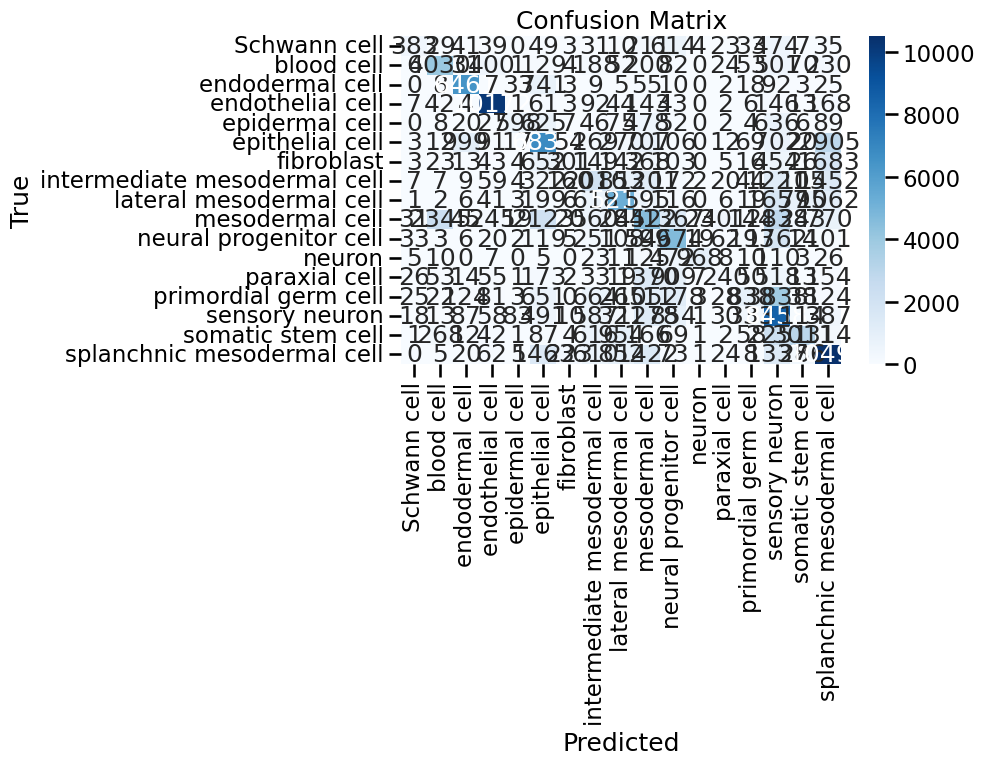

In [13]:
# Initialize the annotator first
annotator = scGPTAnnotator(embedding_key='X_scGPT')

# Then call evaluate_comprehensive
eval = annotator.evaluate_comprehensive(adata, pred_cell_col='pred_cell_type', cell_type_col='cell_type')


True classes: 17, Predicted classes: 17
Common classes: 17
Evaluation Results:
Samples: 140302
Classes: 17
Accuracy: 0.4934
Macro F1: 0.4503850269949609
Weighted F1: 0.47466451140986177
Precision: 0.5079985626815863
Recall: 0.4933500591581018
Metrics stored in adata.uns['classifier_metrics']
Confusion matrix created and stored in adata.uns['figures']['confusion_matrix']


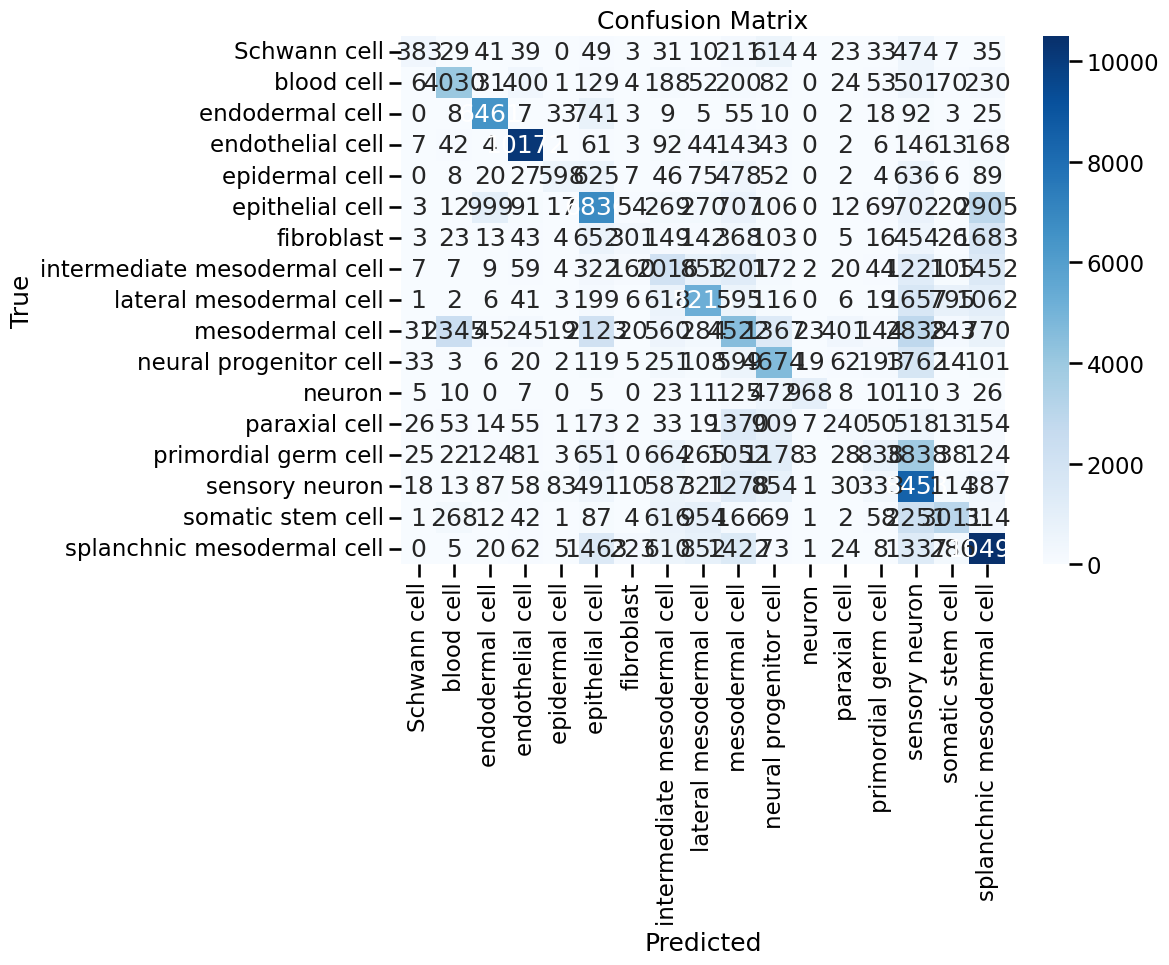

In [17]:
evall = annotator.evaluate_with_visuals(adata, y_pred ='pred_cell_type', y_true='cell_type')